# Naive Bayes Text Likelihood Classification

Naive Bayes classifiers utilize Bayes' theorem under the conditional independence assumption. In Natural Language Processing (NLP), Multinomial Naive Bayes estimates text likelihoods based on word occurrences. This notebook creates a bag-of-words dataset containing 400 reviews across 100 vocabulary coordinates, trains Naive Bayes, and visualizes top class-likelihood indicator words using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Define mock vocabulary words: index 0-9 positive indicators, index 10-19 negative indicators
vocab = [
    'excellent', 'amazing', 'perfect', 'love', 'great', 'awesome', 'enjoy', 'recommend', 'fantastic', 'delight',
    'awful', 'terrible', 'waste', 'worst', 'hate', 'boring', 'poor', 'bad', 'disappoint', 'annoying'
] + [f"word_{i}" for i in range(20, 100)] # Neutral filler words

np.random.seed(92)
n_reviews = 400

# Construct bag-of-words count vectors [400 reviews, 100 features]
X = np.random.poisson(0.15, (n_reviews, 100))
y = np.random.binomial(1, 0.5, n_reviews) # 1 = Positive, 0 = Negative

# Inject indicator counts depending on labels
for idx in range(n_reviews):
    label = y[idx]
    if label == 1:
        # Increase frequency of positive words (index 0-9)
        X[idx, :10] += np.random.poisson(1.2, 10)
    else:
        # Increase frequency of negative words (index 10-19)
        X[idx, 10:20] += np.random.poisson(1.2, 10)

df_text = pd.DataFrame(X, columns=vocab)
df_text['Sentiment'] = y
df_text.head(10)



,excellent,amazing,perfect,love,great,awesome,enjoy,recommend,fantastic,delight,awful,terrible,waste,worst,hate,boring,poor,bad,disappoint,annoying,word_20,word_21,word_22,word_23,word_24,word_25,word_26,word_27,word_28,word_29,word_30,word_31,word_32,word_33,word_34,word_35,word_36,word_37,word_38,word_39,word_40,word_41,word_42,word_43,word_44,word_45,word_46,word_47,word_48,word_49,word_50,word_51,word_52,word_53,word_54,word_55,word_56,word_57,word_58,word_59,word_60,word_61,word_62,word_63,word_64,word_65,word_66,word_67,word_68,word_69,word_70,word_71,word_72,word_73,word_74,word_75,word_76,word_77,word_78,word_79,word_80,word_81,word_82,word_83,word_84,word_85,word_86,word_87,word_88,word_89,word_90,word_91,word_92,word_93,word_94,word_95,word_96,word_97,word_98,word_99,Sentiment
0,1,0,0,0,0,0,0,0,1,0,1,2,1,0,1,1,1,0,1,2,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0
1,0,1,0,0,0,0,0,0,0,0,1,1,0,2,1,2,2,2,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
2,1,1,0,1,1,0,0,0,0,1,0,1,0,1,2,0,0,1,3,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,0,1,1,1,0,2,1,3,0,2,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,2,0,1
4,0,2,1,2,0,0,1,0,0,3,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,2,0,0,0,1
5,1,0,0,0,0,0,0,0,1,0,1,1,0,1,1,1,0,1,1,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
6,1,0,0,1,0,2,1,2,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,1,0,0,0,0,1
7,1,1,1,0,1,1,0,1,2,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
8,1,1,1,2,1,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1
9,2,0,2,0,1,2,2,0,6,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1


## Classifier Fitting & Log Likelihoods

We split reviews into 80/20 train/test segments, fit a Multinomial Naive Bayes estimator, and extract the log likelihood parameters of each word feature.



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Text Classification Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Extract log probabilities for positive features: shape [2 classes, 100 features]
# Difference in log probabilities highlights class indicators
feature_importance = model.feature_log_prob_[1] - model.feature_log_prob_[0]



Naive Bayes Text Classification Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        47
    Positive       1.00      1.00      1.00        33

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## Top Word Indicators Visualization

We sort features by their log likelihood difference and plot the top 10 positive indicators vs. the top 10 negative indicators in a Matplotlib horizontal bar chart.



<cell>:22: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



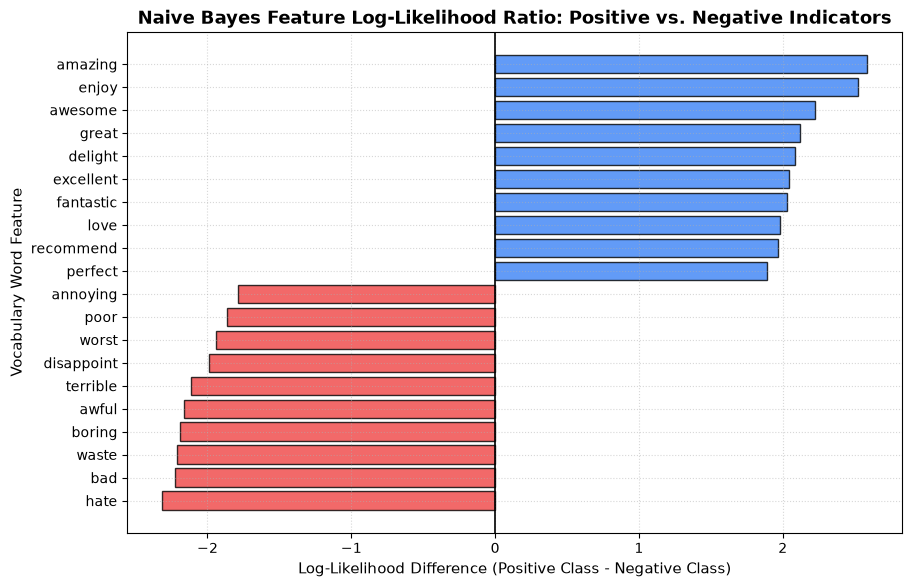

In [3]:
# Sort vocab features
sorted_indices = np.argsort(feature_importance)
top_neg_indices = sorted_indices[:10]
top_pos_indices = sorted_indices[-10:]

# Combine indicators
plot_indices = np.concatenate((top_neg_indices, top_pos_indices))
plot_words = [vocab[idx] for idx in plot_indices]
plot_scores = feature_importance[plot_indices]

# Set color codes
colors = ['#EF4444' if score < 0 else '#3B82F6' for score in plot_scores]

plt.figure(figsize=(10, 6.5))
plt.barh(plot_words, plot_scores, color=colors, edgecolor='black', alpha=0.8)

plt.title('Naive Bayes Feature Log-Likelihood Ratio: Positive vs. Negative Indicators', fontsize=13, fontweight='bold')
plt.xlabel('Log-Likelihood Difference (Positive Class - Negative Class)', fontsize=11)
plt.ylabel('Vocabulary Word Feature', fontsize=11)
plt.axvline(0.0, color='black', linestyle='-', linewidth=1.2)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
